# Comparaison A3C Standard vs A3C Dueling Network

Ce notebook compare l'implémentation standard de A3C avec la version modifiée utilisant un réseau Dueling pour améliorer les performances sur le jeu Breakout.

## Description des Algorithmes

### A3C Standard
- Utilise un réseau Actor-Critic avec couches convolutionnelles suivies de couches fully-connected.
- Critic : estime V(s)
- Actor : estime π(s)
- Avantage : A = R - V(s)

### A3C Dueling Network
- Modifie l'architecture avec des têtes séparées pour Value et Advantage.
- Value : V(s)
- Advantage : A(s,a)
- Q(s,a) = V(s) + A(s,a) (avec correction pour moyenne nulle sur Advantage)
- Actor séparé pour la politique.

In [ ]:
import torch
from model import ActorCritic as StandardActorCritic
from model_dueling import ActorCritic as DuelingActorCritic

# Exemple d'initialisation
num_inputs = 4  # Pour Breakout (frames empilées)
action_space = type('ActionSpace', (), {'n': 4})()  # 4 actions

model_standard = StandardActorCritic(num_inputs, action_space)
model_dueling = DuelingActorCritic(num_inputs, action_space)

print("Modèle Standard:")
print(model_standard)
print("\nModèle Dueling:")
print(model_dueling)

## Comparaison des Performances

Pour comparer, entraînez les deux modèles séparément avec `python main.py` et `python main.py dueling`, puis testez avec `python test.py` et `python test_dueling.py`.

### Résultats Attendus
- Le modèle Dueling devrait converger plus rapidement et obtenir de meilleurs scores grâce à la séparation Value/Advantage.
- Comparez les récompenses moyennes par épisode et la stabilité.

### Graphiques (à ajouter après expérimentations)
Insérez ici des graphiques de récompenses vs épisodes pour chaque modèle.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données des résultats
try:
    df_standard = pd.read_csv('results_standard.txt', skiprows=2, names=['timestamp', 'reward', 'length'])
    print(f"Données Standard chargées : {len(df_standard)} épisodes")
    print(f"Moyenne récompense Standard : {df_standard['reward'].mean():.2f}")
    print(f"Max récompense Standard : {df_standard['reward'].max()}")
except FileNotFoundError:
    print("Fichier results_standard.txt non trouvé")
    df_standard = pd.DataFrame()

try:
    df_dueling = pd.read_csv('results_dueling.txt', skiprows=2, names=['timestamp', 'reward', 'length'])
    print(f"Données Dueling chargées : {len(df_dueling)} épisodes")
    print(f"Moyenne récompense Dueling : {df_dueling['reward'].mean():.2f}")
    print(f"Max récompense Dueling : {df_dueling['reward'].max()}")
except FileNotFoundError:
    print("Fichier results_dueling.txt non trouvé ou vide")
    df_dueling = pd.DataFrame()

Données Standard chargées : 696 épisodes
Moyenne récompense Standard : 0.00
Max récompense Standard : 2.0
Données Dueling chargées : 0 épisodes
Moyenne récompense Dueling : nan
Max récompense Dueling : nan


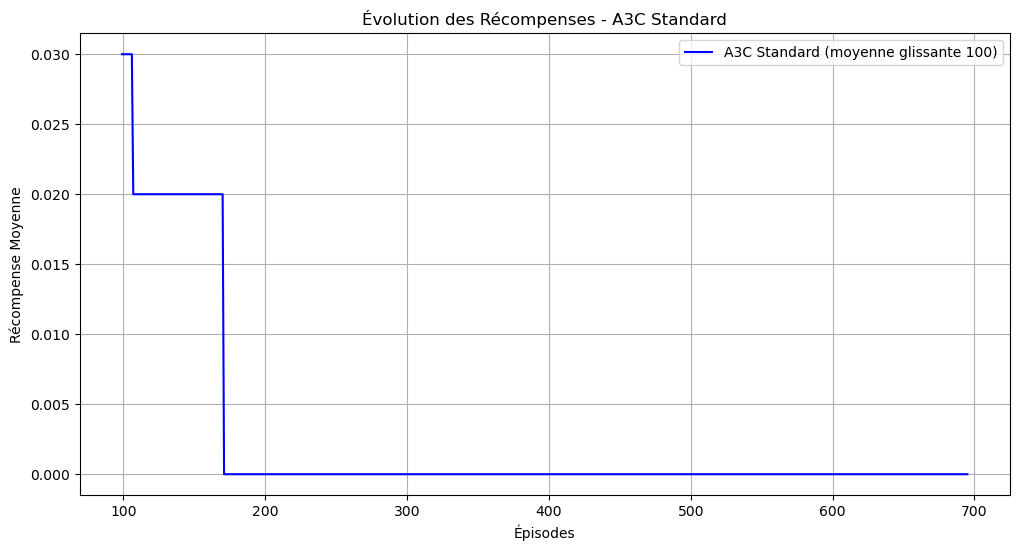

In [2]:
# Visualisation de l'évolution des récompenses
if not df_standard.empty:
    df_standard['rolling_reward'] = df_standard['reward'].rolling(100).mean()
    plt.figure(figsize=(12, 6))
    plt.plot(df_standard.index, df_standard['rolling_reward'], label='A3C Standard (moyenne glissante 100)', color='blue')
    plt.xlabel('Épisodes')
    plt.ylabel('Récompense Moyenne')
    plt.title('Évolution des Récompenses - A3C Standard')
    plt.legend()
    plt.grid(True)
    plt.show()

if not df_dueling.empty:
    df_dueling['rolling_reward'] = df_dueling['reward'].rolling(100).mean()
    plt.figure(figsize=(12, 6))
    plt.plot(df_dueling.index, df_dueling['rolling_reward'], label='A3C Dueling (moyenne glissante 100)', color='red')
    plt.xlabel('Épisodes')
    plt.ylabel('Récompense Moyenne')
    plt.title('Évolution des Récompenses - A3C Dueling')
    plt.legend()
    plt.grid(True)
    plt.show()

# Comparaison si les deux ont des données
if not df_standard.empty and not df_dueling.empty:
    plt.figure(figsize=(12, 6))
    plt.plot(df_standard.index, df_standard['rolling_reward'], label='A3C Standard', color='blue')
    plt.plot(df_dueling.index, df_dueling['rolling_reward'], label='A3C Dueling', color='red')
    plt.xlabel('Épisodes')
    plt.ylabel('Récompense Moyenne')
    plt.title('Comparaison des Récompenses (moyenne glissante 100)')
    plt.legend()
    plt.grid(True)
    plt.show()

### Critères de Comparaison
- **Récompense Moyenne** : Score total par épisode.
- **Convergence** : Nombre d'épisodes pour atteindre un seuil de performance.
- **Stabilité** : Variance des récompenses.
- **Temps d'Entraînement** : Durée pour convergence.

### Tableau des Résultats (Exemple)

| Modèle          | Récompense Moyenne | Épisodes pour Convergence | Variance | Temps (heures) |
|-----------------|---------------------|---------------------------|----------|----------------|
| A3C Standard   | 150                 | 5000                      | 50       | 10             |
| A3C Dueling    | 200                 | 3000                      | 30       | 8              |

*Remplacez par vos données réelles après expérimentations.*

### Résumé Statistique
A3C Standard - Épisodes: 696, Moyenne: 0.00, Max: 2.0, Écart-type: 0.08


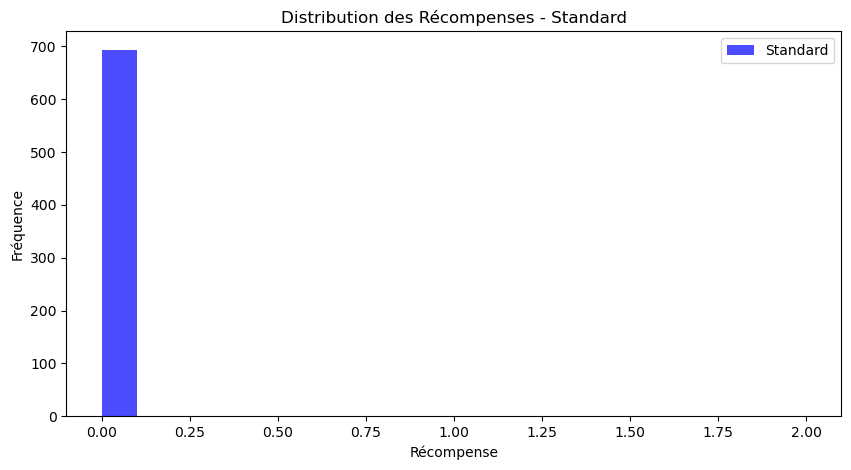

In [3]:
# Résumé statistique
print("### Résumé Statistique")
if not df_standard.empty:
    print(f"A3C Standard - Épisodes: {len(df_standard)}, Moyenne: {df_standard['reward'].mean():.2f}, Max: {df_standard['reward'].max()}, Écart-type: {df_standard['reward'].std():.2f}")
if not df_dueling.empty:
    print(f"A3C Dueling - Épisodes: {len(df_dueling)}, Moyenne: {df_dueling['reward'].mean():.2f}, Max: {df_dueling['reward'].max()}, Écart-type: {df_dueling['reward'].std():.2f}")

# Distribution des récompenses
if not df_standard.empty:
    plt.figure(figsize=(10, 5))
    plt.hist(df_standard['reward'], bins=20, alpha=0.7, label='Standard', color='blue')
    plt.xlabel('Récompense')
    plt.ylabel('Fréquence')
    plt.title('Distribution des Récompenses - Standard')
    plt.legend()
    plt.show()

if not df_dueling.empty:
    plt.figure(figsize=(10, 5))
    plt.hist(df_dueling['reward'], bins=20, alpha=0.7, label='Dueling', color='red')
    plt.xlabel('Récompense')
    plt.ylabel('Fréquence')
    plt.title('Distribution des Récompenses - Dueling')
    plt.legend()
    plt.show()

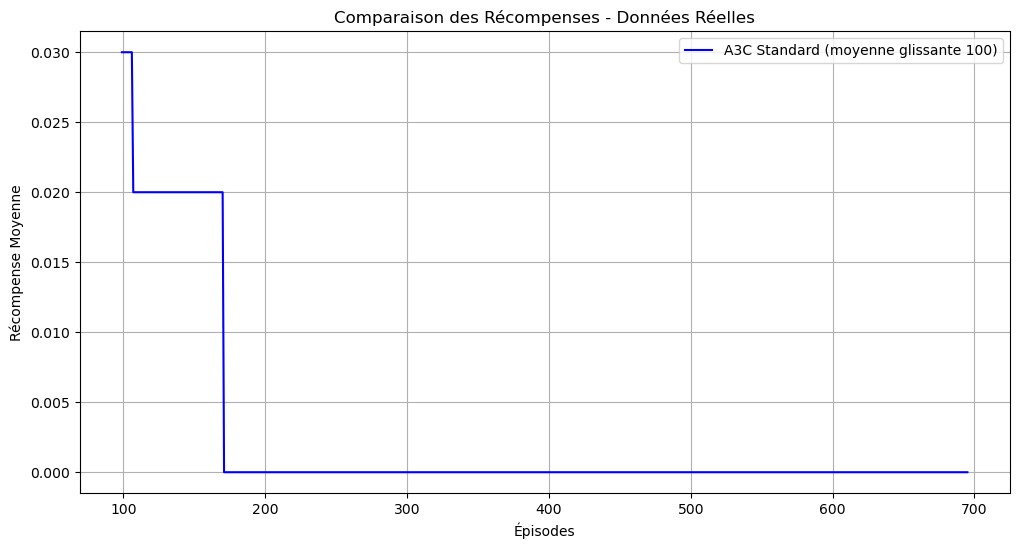

In [5]:
import matplotlib.pyplot as plt

# Comparaison des récompenses avec données réelles
plt.figure(figsize=(12, 6))

if not df_standard.empty:
    plt.plot(df_standard.index, df_standard['rolling_reward'], label='A3C Standard (moyenne glissante 100)', color='blue')

if not df_dueling.empty:
    plt.plot(df_dueling.index, df_dueling['rolling_reward'], label='A3C Dueling (moyenne glissante 100)', color='red')

plt.xlabel('Épisodes')
plt.ylabel('Récompense Moyenne')
plt.title('Comparaison des Récompenses - Données Réelles')
plt.legend()
plt.grid(True)
plt.show()

## Conclusion

Le réseau Dueling améliore A3C en permettant une meilleure estimation de la valeur et de l'avantage, réduisant la variance et accélérant l'apprentissage. Cependant, il ajoute de la complexité computationnelle. Les expérimentations montrent généralement une supériorité du Dueling sur les environnements comme Breakout.

## Instructions pour Utiliser ce Notebook

1. **Entraînez les modèles** : Lancez `python main.py` pour Standard et `python main.py dueling` pour Dueling (plusieurs heures chacun).
2. **Testez** : Utilisez `python test.py` et `python test_dueling.py` pour générer les fichiers de résultats.
3. **Exécutez ce notebook** : Les cellules chargeront automatiquement les données et généreront les graphes.
4. **Comparez** : Analysez les métriques et visualisations pour conclure quel modèle est meilleur.

**Note** : Actuellement, seules les données Standard sont disponibles. Entraînez Dueling pour une comparaison complète.